In [1]:
# specify a PYFILES path that contains the folder LFEAnalysis with this package
PYFILES='/Users/jessicahawthorne/PYFILES'

# and specify a data directory that contains all the LFE data
data_directory='/Users/jessicahawthorne/DATA/LFEAnalysis'

### Introduction

These Python codes and notebooks are designed to analyse the signals generated by low frequency earthquakes.  They assume you have some catalogue of events from previous work and then are designed to download relevant data and analyse it in particular ways.  You can stack collections of LFE signals, examine the events' durations and magnitudes, and look for dilation, among other tools.  

### Notebook 1: Data setup, initiation, and detections

This first notebook is just to get started.  Here we'll make (1) make sure the data directories exist, (2) introduce an lfeanalyse object that will contain most of the data and functions we'll use, and (3) read LFE detections from one catalogue.

In [2]:
# let's import some relevant packages
import numpy as np
import obspy
import matplotlib.pyplot as plt

import os,sys
sys.path.append(os.path.join(PYFILES))
import LFEAnalysis as lfeanalysis

### 1. Specify the data directory

The codes will need to access and save data, so you need to specify a data directory.  If you don't specify a data directory, the data directory will look for the environmental variable \\$DATA and look for data within \\$DATA/LFEAnalysis.

In [3]:
# where all the data are stored: in subdirectories of this directory
# modify as needed
print('All of the data will be retrieved and stored in {:s}'.format(data_directory))

# check that the directory exists
if not os.path.exists(data_directory):
    print('\nBut that directory does not exist...');

All of the data will be retrieved and stored in /Users/jessicahawthorne/DATA/LFEAnalysis


### 2. Initialize an analysis object

We'll now initiate an object that will contain most of the data and relevant functions: an lfeanalyse object.  

For most purposes, we'll analyse one family of LFEs at a time: on family of detections that recur at a single location.  Here we've picked family \#74.  We've also specified a region: Cascadia.

In [4]:
# now we can create an analysis object
# we choose a particular family: here #74
lf=lfeanalysis.lfeanalyse(fnum=74,data_directory=data_directory,region='Cascadia')

print('We are analysing LFE family {:d} in {:s}'.format(lf.fnum,lf.region))

We are analysing LFE family 74 in Cascadia


### 3. Read in the list of detections

We can now read in the times of detections in this family in an LFE catalogue of interest.

In [5]:
# pick the catalogue to use
# some catalogues are chosen by default for the region of interest
print('By default for {:s}, we are using the {:s} catalogue'.format(lf.region,lf.catalog))

# but we can specify another if we like
# here we use the catalog developed by Bostock et al, 2012
lf.catalog='Bostock'

print('We are now are using the {:s} catalogue'.format(lf.catalog))

By default for Cascadia, we are using the Bostock catalogue
We are now are using the Bostock catalogue


In [7]:
# now read the detection times and any existing templates
lf.read_detection_info()

In [8]:
# the most important thing here is the times of detected LFEs
# all of these occur in the family of interest 
lf.tms

array([UTCDateTime(2003, 2, 26, 5, 54, 40, 675000),
       UTCDateTime(2003, 2, 26, 9, 36, 13, 675000),
       UTCDateTime(2003, 2, 26, 10, 13, 9, 750000), ...,
       UTCDateTime(2013, 10, 5, 16, 25, 17, 600000),
       UTCDateTime(2013, 10, 5, 16, 28, 11, 325000),
       UTCDateTime(2013, 10, 10, 18, 54, 14, 875000)],
      shape=(3857,), dtype=object)

In [9]:
# the LFE magnitudes may also be available
lf.mags

array([1.734, 1.697, 1.717, ..., 1.753, 1.583, 1.996], shape=(3857,))

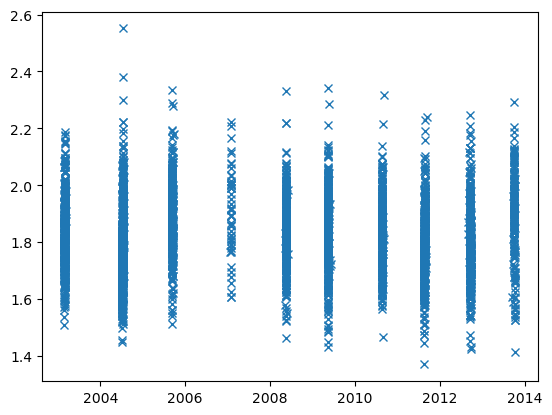

In [10]:
# it might be interesting to look at these detections through time
plt.plot([tm.datetime for tm in lf.tms],lf.mags,marker='x',linestyle='none');

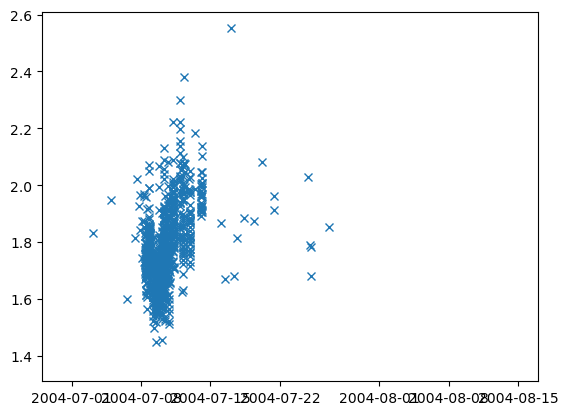

In [11]:
# we can also look at a shorter time interval
plt.plot([tm.datetime for tm in lf.tms],lf.mags,marker='x',linestyle='none');
t1=obspy.UTCDateTime(2004,6,28)
plt.xlim([t1,t1+86400*50]);

In [12]:
# we'll note the location of this family
print('LFE location: ',lf.floc)

LFE location:  [-123.7003   48.1192   29.09  ]


### 4. Also note any existing templates

In [13]:
# we may also have existing stacks of the LFEs from previous work
# these are read in with read_detection_info and saved as obspy traces
# we'll have a look at them in the next notebook
lf.sttemp

177 Trace(s) in Stream:

.B012..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:59.975000Z | 40.0 Hz, 2400 samples
...
(175 other traces)
...
.B004..Z | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:59.975000Z | 40.0 Hz, 2400 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

### 4. Pick the stations to use for analysis

In [14]:
# if a previous study has already made stacks of LFEs: templates,
# let's identify the arrival times and signal to noise power ratios in those stacks
lf.pick_templates(minsnr=5)

In [15]:
# the signal to noise ratio estimated are saved in a dictionary
lf.temp_snrs

{'A04A': 5.835845450654718,
 'A04D': 5.5235563782208725,
 'B001': 2.096527009389917,
 'B003': 8.38780346336646,
 'B004': 6.066802531267702,
 'B007': 13.655727317038611,
 'B011': 47.56714694878726,
 'B012': 2.0572412700406018,
 'B04A': 1.9286504674680123,
 'B926': 121.58119985218235,
 'B927': 5.334588485828302,
 'B928': 6.555337276695893,
 'BIB': nan,
 'BMSB': 2.091556613847129,
 'BPCB': 31.334153214496176,
 'CPLB': 1.7905077126598437,
 'ENGB': 1.9083591841793002,
 'GHNB': 4.784930599183665,
 'GLBC': 6.3740600942949595,
 'GOBB': nan,
 'GOWB': 82.24148895823787,
 'JRBC': 15.961163899191089,
 'KELB': 15.898569889936066,
 'KHVB': 28.84447516395185,
 'KLNB': 33.597010095794055,
 'LCBC': 2.170282560042523,
 'LOP3': 1.230037255577648,
 'LRIV': 7.283641045533715,
 'LZB': 76.17420287635889,
 'MGB': 36.175717489469065,
 'MGCB': 57.41064586535943,
 'NLLB': 50.39382428597287,
 'OPC': 1.807880357123905,
 'OZB': 4.998336824484352,
 'PFB': 38.38005184342541,
 'PGC': 55.19015960828753,
 'PHYB': 25.928

In [16]:
# and the stations that have signal to noise ratios bigger 
# than minsnr input above are listed 
lf.stns

array(['A04A', 'A04D', 'B003', 'B004', 'B007', 'B011', 'B926', 'B927',
       'B928', 'BPCB', 'GLBC', 'GOWB', 'JRBC', 'KELB', 'KHVB', 'KLNB',
       'LRIV', 'LZB', 'MGB', 'MGCB', 'NLLB', 'PFB', 'PGC', 'PHYB', 'SHB',
       'SHDB', 'SHVB', 'SILB', 'SNB', 'SOK1', 'SOK2', 'SOK4', 'SOK5',
       'SOK6', 'SOKB', 'SSIB', 'TFRB', 'TSJB', 'TWBB', 'TWGB', 'TWKB',
       'VGZ', 'YOUB'], dtype='<U4')

If you plan to download data, the stations to be used are saved in lf.stns.  So if you don't have templates from a previous study, you can just create a list of stations and save it as lf.stns.

In [17]:
# for this example, though, we do have a template, and the function 
# pick_template picks the time window that is largest relative to the time window before it
# the start time of the data window is given by the 't0' parameter in the seismogram

# let's pick a trace
tr=lf.sttemp[0]
print('A trace:\n',tr)

# and look at its value of t0
print('\nAll the trace\'s statistics:\n',tr.stats)
print('\nThe window\'s start time:\n',tr.stats.t0)

A trace:
 .B012..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:00:59.975000Z | 40.0 Hz, 2400 samples

All the trace's statistics:
          network: 
         station: B012
        location: 
         channel: E
       starttime: 1970-01-01T00:00:00.000000Z
         endtime: 1970-01-01T00:00:59.975000Z
   sampling_rate: 40.0
           delta: 0.025
            npts: 2400
           calib: 1.0
             snr: 2.0572412700406018
              t0: 54.45
              t1: 59.45

The window's start time:
 54.45
